# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Mauricio Aguilar Gómez"            # Tu nombre completo
MATRICULA = "82141"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "homicidios"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"
print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Mauricio Aguilar Gómez
Matrícula: 82141
Dataset asignado: homicidios


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\mauri\OneDrive\Documents\La salle bajio files\Big data\Examen_primer_parcial\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: homicidios
Descripcion: Numero de homicidios intencionales por anio (homicidios)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,2009,1115.000,Asia
1,Afghanistan,AFG,2010,983.000,Asia
2,Afghanistan,AFG,2011,1231.000,Asia
3,Afghanistan,AFG,2012,1948.000,Asia
4,Afghanistan,AFG,2015,3367.000,Asia
5,Afghanistan,AFG,2016,2318.000,Asia
6,Afghanistan,AFG,2017,2424.000,Asia
7,Afghanistan,AFG,2018,2474.000,Asia
8,Afghanistan,AFG,2019,2712.000,Asia
9,Afghanistan,AFG,2020,2570.000,Asia


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(4914, 5)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4914 entries, 0 to 4913
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   entity       4914 non-null   str    
 1   code         4399 non-null   str    
 2   year         4914 non-null   int64  
 3   valor        4914 non-null   float64
 4   owid_region  4220 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 192.1 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count      4914.000000
mean       8582.853861
std       37590.820449
min           0.000000
25%          37.000000
50%         256.500000
75%        1171.968475
max      450728.880000
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           515
year             0
valor            0
owid_region    694
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

Lo que noto es que varios paises no tienen owid_region que parece ser el continente en el cual se registran los homicidios ni tampoco código de país, los demás datos están completos. Sobre el rango de años, están almacenados con int64. Ahora, sobre el tipo de variable con la que trabajaré, se me hace muy raro que la media (50%) sea de apenas 256.5 mientras que la mediana se pasa a 8582.85.

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [10]:
# Pregunta 1
# Tu codigo aqui
filtro = config['filtro_paises']
df_paises = df.dropna(subset=[filtro])
print("Total de países distintos:", df_paises['entity'].nunique())

resultado = (
    df_paises.groupby("entity")["valor"]
    .mean()
    .sort_values(ascending=False)
)
print("\n10 países con mayor valor:")
print(resultado.head(10))

print("\n10 países con menor valor:")
print(resultado.tail(10))

Total de países distintos: 200

10 países con mayor valor:
entity
Nigeria          47828.000000
Brazil           45890.081088
India            45533.272727
Russia           26643.272727
South Africa     20690.758621
Mexico           19765.029412
Colombia         19180.823529
United States    18447.838710
China            15630.727273
Pakistan         10231.000000
Name: valor, dtype: float64

10 países con menor valor:
entity
Saint Pierre and Miquelon    0.500000
Andorra                      0.454545
Montserrat                   0.428571
Liechtenstein                0.423077
Gibraltar                    0.333333
Monaco                       0.333333
Tuvalu                       0.333333
Saint Helena                 0.062500
San Marino                   0.058824
Vatican                      0.000000
Name: valor, dtype: float64


**Interpretación:**

Podemos ver que al aplicar un filtro y tomar los países únicos mediante .nunique() tenemos un total de 200 países distintos. De esos, los que más homicidios por 100,000 personas al año tienen son Nigeria, Brazil e India (top 3), los demás ahí están. Y los que menos tienen son el Vaticano, San Marino y Santa Helena (top 3) con menos homicidios.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [11]:
# Pregunta 2
# Tu codigo aqui
mexico = df_paises[df_paises['entity'] == 'Mexico']
uk = df_paises[df_paises['entity'] == 'United Kingdom']

anio_min = max(mexico['year'].min(), uk['year'].min())
anio_max = min(mexico['year'].max(), uk['year'].max())

mexico_comun = mexico[(mexico['year'] >= anio_min) & (mexico['year'] <= anio_max)]
uk_comun = uk[(uk['year'] >= anio_min) & (uk['year'] <= anio_max)]

print("México:")
print(mexico_comun)

print("United Kingdom:")
print(uk_comun)

México:
      entity code  year    valor    owid_region
2718  Mexico  MEX  1990  14493.0  North America
2719  Mexico  MEX  1991  15128.0  North America
2720  Mexico  MEX  1992  16594.0  North America
2721  Mexico  MEX  1993  16040.0  North America
2722  Mexico  MEX  1994  15839.0  North America
2723  Mexico  MEX  1995  15612.0  North America
2724  Mexico  MEX  1996  14505.0  North America
2725  Mexico  MEX  1997  13552.0  North America
2726  Mexico  MEX  1998  13656.0  North America
2727  Mexico  MEX  1999  12249.0  North America
2728  Mexico  MEX  2000  10737.0  North America
2729  Mexico  MEX  2001  10285.0  North America
2730  Mexico  MEX  2002  10088.0  North America
2731  Mexico  MEX  2003  10087.0  North America
2732  Mexico  MEX  2004   9329.0  North America
2733  Mexico  MEX  2005   9921.0  North America
2734  Mexico  MEX  2006  10452.0  North America
2735  Mexico  MEX  2007   8867.0  North America
2736  Mexico  MEX  2008  14006.0  North America
2737  Mexico  MEX  2009  19803.0

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [12]:
# Pregunta 3
# Tu codigo aqui
paises = ['Mexico', 'Japan', 'South Africa', 'United Kingdom', 'Australia']
df_5_paises = df_paises[df_paises['entity'].isin(paises)]

anio_reciente = df_5_paises.groupby('entity')['year'].max().min()
print("Año más reciente disponible para los 5 países:", anio_reciente)

comparacion = df_5_paises[df_5_paises['year'] == anio_reciente]

comparacion = comparacion[['entity', 'year', 'valor']].sort_values(by='valor', ascending=False)
print("\nComparación:")
print(comparacion)

valor_max = comparacion['valor'].max()
valor_min = comparacion['valor'].min()
diferencia = valor_max - valor_min

print("\nValor más alto:", valor_max)
print("Valor más bajo:", valor_min)
print("Diferencia:", diferencia)

Año más reciente disponible para los 5 países: 2021

Comparación:
              entity  year    valor
2749          Mexico  2021  35700.0
4077    South Africa  2021  25181.0
4637  United Kingdom  2021    757.0
2247           Japan  2021    285.0
327        Australia  2021    193.0

Valor más alto: 35700.0
Valor más bajo: 193.0
Diferencia: 35507.0


**Interpretación:**

Aquí, no pude hacer la comparación fácilmente, ya que algunos países tenían datos hasta el 2023 mientras que Reino Unido solo tenía hasta el 2021. Debido a esto, tuve que aplicar un filtrado para saber hasta qué año tienen datos TODOS los países. Una vez encontrado este año, simplemente teníamos que extraer los datos de ese año (más reciente posible) y finalmente comparar al mayor (México) con el menor (Australia) y restar sus valores para obtener la diferencia.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [13]:
# Pregunta 4
# Tu codigo aqui
latinoamerica = ['Mexico', 'Colombia', 'Argentina']
asia = ['China', 'Japan', 'Vietnam']

todos_paises = latinoamerica + asia
df_grupos = df_paises[df_paises['entity'].isin(todos_paises)]

anio_reciente = df_grupos.groupby('entity')['year'].max().min()
print("Año más reciente disponible para ambos grupos:", anio_reciente)

df_anio = df_paises[df_paises['year'] == anio_reciente]

df_latam = df_anio[df_anio['entity'].isin(latinoamerica)]
df_asia = df_anio[df_anio['entity'].isin(asia)]

promedio_latam = df_latam['valor'].mean()
promedio_asia = df_asia['valor'].mean()

print(f"\nPromedio Latinoamérica ({anio_reciente}):", promedio_latam)
print(f"Promedio Asia ({anio_reciente}):", promedio_asia)

Año más reciente disponible para ambos grupos: 2011

Promedio Latinoamérica (2011): 15283.666666666666
Promedio Asia (2011): 4605.0


**Interpretación:**

Para realizar esta comparación, primero definí los dos grupos con los países indicados y, al igual que en el ejercicio anterior, busqué el año más reciente en el que todos los países de ambas regiones tuvieran datos registrados para que la comparación fuera justa. Una vez filtrado ese año en común, calculé el promedio del indicador para cada bloque, donde se puede observar la diferencia entre ambos grupos, teniendo Latinoamérica un promedio de 15283.66 frente a Asia que obtuvo 4605.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [14]:
# Pregunta 5
# Tu codigo aqui
pais_elegido = 'Italy'
df_pais = df_paises[df_paises['entity'] == pais_elegido]

df_pais = df_pais[['entity', 'year', 'valor']].sort_values(by='year')

valor_max = df_pais['valor'].max()
valor_min = df_pais['valor'].min()
fila_max = df_pais[df_pais['valor'] == valor_max]
fila_min = df_pais[df_pais['valor'] == valor_min]
anio_max = fila_max['year'].values[0]
anio_min = fila_min['year'].values[0]

print(f"País analizado: {pais_elegido}")
print(f"Valor máximo: {valor_max} (ocurrido en el año {anio_max})")
print(f"Valor mínimo: {valor_min} (ocurrido en el año {anio_min})")

print("\nPrimeros registros:")
print(df_pais.head())
print("\nÚltimos registros:")
print(df_pais.tail())

País analizado: Italy
Valor máximo: 1938.0 (ocurrido en el año 1991)
Valor mínimo: 285.0 (ocurrido en el año 2020)

Primeros registros:
     entity  year   valor
2150  Italy  1990  1794.0
2151  Italy  1991  1938.0
2152  Italy  1992  1476.0
2153  Italy  1993  1071.0
2154  Italy  1994   969.0

Últimos registros:
     entity  year  valor
2177  Italy  2019  317.0
2178  Italy  2020  285.0
2179  Italy  2021  303.0
2180  Italy  2022  322.0
2181  Italy  2023  338.0


**Interpretación:**

Para este análisis elegí a Italia. Al revisar la serie de tiempo disponible (1990–2023), su valor máximo fue de 1938.0 en 1991 y su mínimo de 285.0 en 2020. La tendencia general es claramente decreciente, ya que el indicador muestra una reducción constante a lo largo de las décadas, pasando de casi 1,800 casos a inicios de los noventa a mantenerse en torno a los 300 en los años más recientes. Pienso que el periodo en el que tenía un valor alto se debía al conflicto entre las mafias Italianas y el estado.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [15]:
# Pregunta 6
# Tu codigo aqui

df_mexico = df_paises[df_paises['entity'] == 'Mexico']
df_mexico = df_mexico[['entity', 'year', 'valor']].sort_values(by='year')

primer_registro = df_mexico.iloc[0]
ultimo_registro = df_mexico.iloc[-1]

anio_inicial = int(primer_registro['year'])
valor_inicial = primer_registro['valor']

anio_final = int(ultimo_registro['year'])
valor_final = ultimo_registro['valor']

cambio_porcentual = ((valor_final - valor_inicial) / valor_inicial) * 100

print(f"Año inicial ({anio_inicial}): {valor_inicial}")
print(f"Año final ({anio_final}): {valor_final}")
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")

Año inicial (1990): 14493.0
Año final (2023): 32252.0
Cambio porcentual: 122.54%


**Interpretación:**

Al comparar los datos de México entre su primer año registrado (1990 con un valor de 14,493) y el último (2023 con 32232), se obtiene un cambio porcentual de 122.54%, lo cual representa un incremento en homicidios. Considero que este comportamiento se debe a factores como el crecimiento demográfico, la evolución en las condiciones de seguridad pública, entre muchas otras.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [16]:
# Pregunta 7
# Tu codigo aqui
anio_reciente = df_paises['year'].max()
df_reciente = df_paises[(df_paises['year'] == anio_reciente) & (df_paises['valor'].notnull())]

valores = df_reciente['valor'].to_numpy()

media = np.mean(valores)
mediana = np.median(valores)
desviacion = np.std(valores)

print(f"Año analizado: {anio_reciente}")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación estándar: {desviacion:.2f}")

Año analizado: 2024
Media: 1402.50
Mediana: 209.50
Desviación estándar: 3319.74


**Interpretación:**

Para el año 2024, la media de homicidios fue de 1402.5 mientras que la mediana se situó en 209.5, con una desviación estándar de 3319.74. La gran diferencia entre la media y la mediana muestra un sesgo positivo debido a que pocos países concentran cifras muy altas de homicidios frente a la mayoría.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

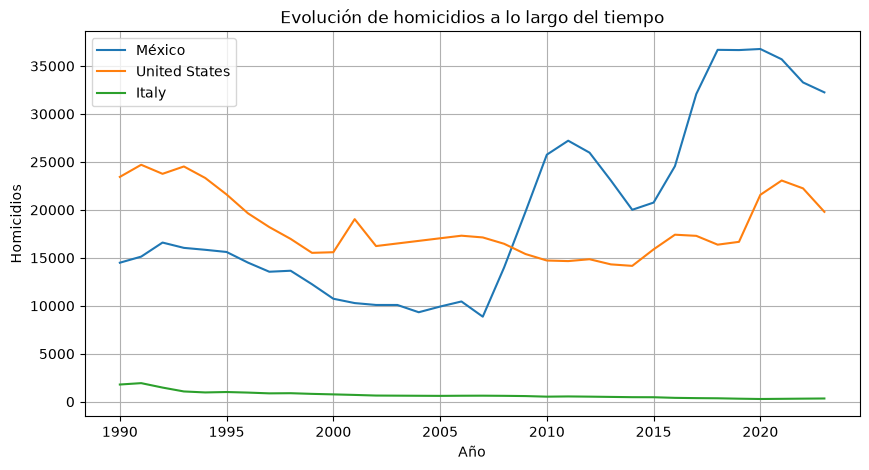

In [17]:
# Pregunta 8
# Tu codigo aqui
p1 = df_paises[df_paises['entity'] == 'Mexico'].sort_values('year')
p2 = df_paises[df_paises['entity'] == 'United States'].sort_values('year')
p3 = df_paises[df_paises['entity'] == 'Italy'].sort_values('year')

plt.figure(figsize=(10, 5))

plt.plot(p1['year'], p1['valor'], label='México')
plt.plot(p2['year'], p2['valor'], label='United States')
plt.plot(p3['year'], p3['valor'], label='Italy')

plt.title('Evolución de homicidios a lo largo del tiempo')
plt.xlabel('Año')
plt.ylabel('Homicidios')
plt.legend()
plt.grid(True)
plt.show()

**Interpretación:**

Al inicio, puse a México, Italia y Japón, pero debido a que México tiene demasiados comparado a esos dos, decidí incluir a Estados Unidos. Con esto se logra una escala mucho más comparable. Se aprecia que en los años 90 Estados Unidos superaba a México en homicidios, pero a partir de 2008 México experimentó un incremento acelerado que lo colocó muy por encima de ambos países, mientras que Italia se mantuvo en niveles mínimos y constantes durante casi todo el periodo.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

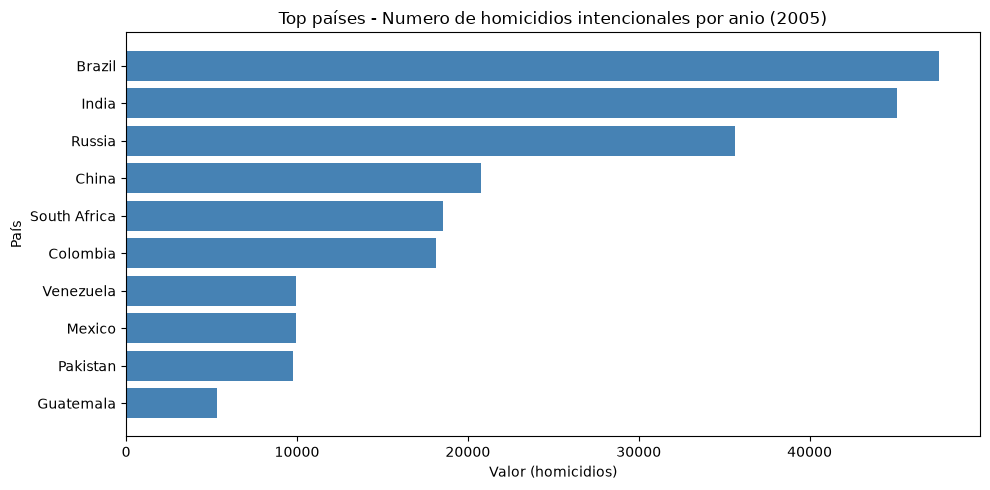

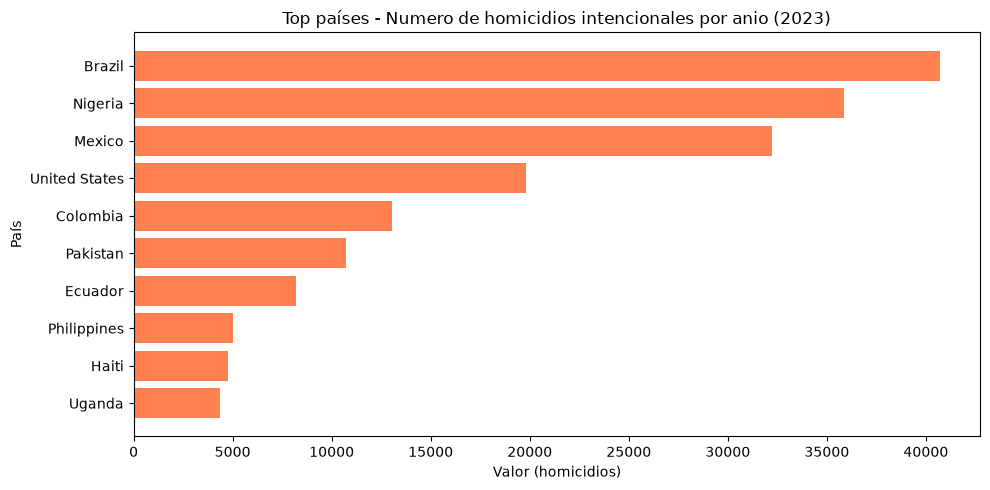

In [18]:
# Pregunta 9
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_nacimiento = 2005
anio_reciente = 2023

top_nacimiento = (
    df_paises[df_paises['year'] == anio_nacimiento]
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_nacimiento['entity'], top_nacimiento['valor'], color='steelblue')
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_nacimiento})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_2023 = (
    df_paises[df_paises['year'] == anio_reciente]
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_2023['entity'], top_2023['valor'], color='coral')
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_reciente})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretación:**

Al contrastar ambas gráficas se aprecian movimientos notables en el ranking. Mientras que en 2005 los primeros puestos eran encabezados por Brasil, India y Rusia, para 2023 países como México escalaron posiciones de forma significativa hacia la parte alta del Top 10, reflejando un desplazamiento del volumen de homicidios hacia ciertas regiones de América Latina.

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Al trabajar con este dataset aprendí sobre el comportamiento histórico de los homicidios en diferentes países y regiones.

El patrón más claro fue la enorme desigualdad que existe entre regiones: mientras que países como México, Brasil o Estados Unidos concentran cifras muy altas, lugares como Europa o Asia se mantienen en niveles mínimos y a la baja. En el caso de México, noté un incremento enorme (+122.54%) entre 1990 y 2023, disparándose sobre todo a partir de 2008.

La mayor limitación que encontré es que los datos vienen en números absolutos y no en tasas por cada 100 mil habitantes, lo que hace que los países más poblados siempre se vean peor aunque proporcionalmente no lo sean. Además, varios países no tenían la misma cobertura de años y cortaban antes (como en 2021).

Si tuviera más tiempo, calcularía las tasas usando la población total de cada país para hacer comparaciones más justas y justificaría las tendencias cruzando los datos con factores socioeconómicos o de seguridad.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
